# STEP6 영향분석 (회귀분석 + FPI 구간별 성과비교)

## 분석 개요 및 목적
- 목적 : 프랜차이즈 밀집도(FPI)가 독립 브랜드의 성과(별점) 및 평판(감성점수)에 미치는 영향을 다각도로 검증함.
- 분석 대상 FPI : 앞선 STEP5 민감도 분석에서 가장 통계적 유의성이 높았던 fpi_100m 변수를 최종 독립변수로 채택함.

| 단계 | 내용 |
|---|---|
| STEP6-1 | 다중회귀분석(OLS Regression) 수행 |
| STEP6-2 | FPI 기반 경쟁압력 구간 분류 |
| STEP6-3 | 구간별 성과 비교 및 통계적 유의성 검정(ANOVA 및 사후검정) |
| STEP6-4 | 분석 결과 시각화 및 해석 |

---
입력 데이터
- `biz_sentiment_with_fpi.csv`

# 공통라이브러리 및 설정

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

PATH_to_data = r"C:\Users\seonu\Documents\yelp-franchise-analysis\results"
PATH_to_save = r"C:\Users\seonu\Documents\yelp-franchise-analysis\results"

# 데이터 준비

+) neighborhood(상권 구역) 컬럼을 분석해보니, 값이 비어있는 매장들이 일부 존재하여 코드 내에 Unknown이라는 가상 상권으로 채워넣어 4,818개의 독립 매장 데이터를 전부 앞으로 진행할 회귀분석에 반영하도록 함.

In [2]:
# 데이터 불러오기
df = pd.read_csv(f"{PATH_to_data}/biz_sentiment_with_fpi.csv")

# 분석 대상인 독립브랜드만 필터링
indie_df = df[df['is_franchise'] == False].copy()

# neighborhood 컬럼의 결측치(NaN)를 'Unknown' 상권으로 대체
indie_df['neighborhood'] = indie_df['neighborhood'].fillna('Unknown')

---
# STEP6-1 다중회귀분석(OLS Regression)

독립 매장의 성과를 다차원적으로 평가하기 위해 2개의 회귀 모델을 독립적으로 구성하여 분석한다.

- [모델 1] 종속변수 : 독립 브랜드 별점 (stars)
- [모델 2] 종속변수 : 종속변수: 독립 브랜드 감성점수(tfidf_sentiment)

    공통 독립변수(X) : 
- 핵심변수 :  fpi_100m (프랜차이즈 압력 지수)
- 통제변수(업체 속성) : review_count (매장 규모/인지도 통제용)
- 통제변수(상권) : neighborhood 

분석 도구: statsmodels.api.OLS

In [3]:
# 상권 변수(neighborhood) 더미 변수화 (+ 다중공선성 방지)
neighborhood_dummies = pd.get_dummies(indie_df['neighborhood'], prefix='nh', drop_first=True, dtype=float)

# 독립변수 데이터셋(X) 구성
X = indie_df[['fpi_100m', 'review_count']].copy()
X = pd.concat([X, neighborhood_dummies], axis=1)
X = sm.add_constant(X) # 상수항 추가

# 종속변수(Y) 설정
y_stars = indie_df['stars']
y_sentiment = indie_df['tfidf_sentiment']

In [4]:
##[모델1] 독립 브랜드 별점(stars) 회귀분석
print("\n" + "="*70)
print("     [모델 1 결과] 독립 브랜드 별점(Stars)에 미치는 영향")
print("="*70)
model_stars = sm.OLS(y_stars, X).fit()
print(model_stars.summary().tables[1]) #결과출력


     [모델 1 결과] 독립 브랜드 별점(Stars)에 미치는 영향
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.6954      0.222     16.622      0.000       3.260       4.131
fpi_100m               0.2817      0.098      2.886      0.004       0.090       0.473
review_count           0.0003   2.69e-05     10.122      0.000       0.000       0.000
nh_Centennial         -0.1180      0.233     -0.507      0.612      -0.574       0.338
nh_Chinatown          -0.0179      0.226     -0.079      0.937      -0.461       0.425
nh_Downtown            0.0224      0.225      0.099      0.921      -0.420       0.464
nh_Eastside           -0.1361      0.225     -0.606      0.545      -0.577       0.304
nh_Northwest          -0.1296      0.229     -0.566      0.572      -0.579       0.320
nh_South Summerlin    -0.2353      0.238     -0.991      0.322      -0.701       0.230
nh

[모델1] 독립브랜드 별점(stars)에 미치는 영향
1. 프랜차이즈 밀집도(fpi_100m)의 영향
* 수치 해석: 회귀계수가 0.2817이고, P-value가 0.004이다.
* 설명: P-value가 유의수준 alpha=0.05보다 작다. 이는 FPI의 독립브랜드 별점에 미치는 영향이 유의미하다고 볼 수 있다. 상권의 위치나 매장의 리뷰 수 효과를 모두 동일하게 맞춰놓고 비교하더라도, 100m 이내 프랜차이즈 압력(FPI)이 1단위 증가할 때마다 독립 매장의 별점은 약 0.28점 증가함을 의미한다.
* 프랜차이즈가 밀집해 고압력이 가해지는데도 살아남은 독립 매장들은 오히려 프랜차이즈와의 차별화(맛,서비스,독창성 등)에 성공하여 소비자들에게 더 높은 별점을 받고 있음을 시사한다. 즉, 100m 이내 초근접 구역에서 대기업 침투는 일반 독립 매장에게는 위기이지만, 실력있는 독립 매장에게는 오히려 독점적 경쟁력을 부각하는 계기가 될 수 있다.

2. 매장 규모 및 인지도(review_count)의 영향(통제변수)
* 수치 해석: 회귀계수가 0.0003, P-value가 0.0000이다.
* 설명: P-value가 0에 근접하기 때문에 통계적으로 확실한 양(+)의 영향이 있다. 다만 계수 값이 0.0003으로 매우 작기에 리뷰 수가 약 3,000개 이상 쌓여야 별점이 1점 올라가는 수준이다. 누적 리뷰가 많은 유명 매장일수록 미세하게 별점이 높은 경향이 있음을 통제해준 것이다.

3. 상권 구역(nh_...)의 영향(통제변수)
* 수치 해석: P-value들이 대부분 0.05보다 훨씬 크다.
* 설명: 단, 하나의 예외(nh_The Strip), 라스베이거스 메인 관광지 'The Strip'상권의 계수는 -0.3820이며, P-value는 0.088로 유의수준 alpha=0.10 기준에선 어느정도 유의미하다. 관광객들이 몰리고 기대치가 높은 메인 스트립 지역 특성상, 독립 매장들이 다른 로컬 지역에 비해 별점을 따기가 약 0.38점정도 더 까다롭고 엄격하다는 상권 특성을 잡아낸 것이다.

-> 독립브랜드의 매장 규모(리뷰 수)와 지리적 상권 특성(The Strip 등)을 통제한 다중회귀분석을 실시한 결과, 반경 100m내 프랜차이즈 밀집도(FPI)는 독립 매장의 별점(Stars)에 통계적으로 매우 유의미한 (+)의 영향을 미치는 것으로 나타났다.(coef=0.2817, P-value=0.004) 이는 프랜차이즈가 극도로 밀집한 초근접 경쟁 환경 속애서 생존해 있는 독립 브랜드의 경우, 프랜차이즈와의 전면전에서 유의미한 차별화와 브랜드 경쟁력을 확보하여 소비자로부터 도리어 더 높은 별점 평가를 받고있음을 실증한다.

In [5]:
##[모델 2] 독립 브랜드 감성점수(tfidf_sentiment) 회귀분석
print("\n" + "="*70)
print("     [모델 2 결과] 독립 브랜드 감성점수(Sentiment)에 미치는 영향")
print("="*70)
model_sentiment = sm.OLS(y_sentiment, X).fit()
print(model_sentiment.summary().tables[1])


     [모델 2 결과] 독립 브랜드 감성점수(Sentiment)에 미치는 영향
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0167      0.004      3.905      0.000       0.008       0.025
fpi_100m               0.0028      0.002      1.492      0.136      -0.001       0.006
review_count        4.265e-06   5.18e-07      8.234      0.000    3.25e-06    5.28e-06
nh_Centennial         -0.0077      0.004     -1.727      0.084      -0.017       0.001
nh_Chinatown          -0.0024      0.004     -0.555      0.579      -0.011       0.006
nh_Downtown           -0.0047      0.004     -1.076      0.282      -0.013       0.004
nh_Eastside           -0.0064      0.004     -1.486      0.137      -0.015       0.002
nh_Northwest          -0.0088      0.004     -1.983      0.047      -0.017      -0.000
nh_South Summerlin    -0.0062      0.005     -1.348      0.178      -0.015       0.

[모델2] 독립 브랜드 감성점수(Sentiment)에 미치는 영향
1. 프랜차이즈 밀집도(fpi_100m)의 영향
* 수치 해석: coef는 0.0028이지만, P-value는 0.136이다.
* 설명: 유의수준 alpga=0.05보다 크므로, 영향이 통계적으로 유의하지 않다. 다른 조건(리뷰 수, 상권)을 동일하게 통제하고 나면 FPI가 감성점수를 직접적으로 변화시킨다고 볼 수 없다.
* 앞서 [모델1]에서 FPI가 높아질 때 별점(Stars)은 유의미하게 올라간다고 분석하였으나, '텍스트 리뷰의 감성점수'에는 영향이 없다고 해석되었다. 이는 소비자들이 초근접 경쟁에서 살아남은 독립 매장에 별점 자체는 후하게 주는 경향이 있으나, 막상 리뷰 글로 작성하는 체험 만족도의 상세한 표현이나 평판(감성점수)은 프랜차이즈의 유무보다는 다른 요소(맛, 인테리어, 가격 등)에 의해 결정됨을 의미한다.

2. 매장 규모 및 인지도(review_count)의 영향(통제변수)
* 수치 해석: coef는 0.000004265, P-value는 0.000이다.
* 설명: 수치 자체는 미미하나, 통계적으로는 확실한 양(+)의 관계다. 즉, 손님이 많이 찾고 리뷰가 많이 쌓인 매장일수록 텍스트 리뷰 속의 긍정적인 감성표현 비율이 안정적으로 높게 나타난다. 유명한 대형 매장일수록 신뢰도가 높고 긍정 평판을 유지하기 유리하다는 기저 효과를 잘 반영했다.

3. 상권 구역(nh_...)의 영향(통제변수)
* 모델1에선 대부분의 상권이 유의하지 않았으나, 감성점수 모델에선 유의미하게 긍정 뉘앙스가 깎이는 상권들이 발견되었다.
* nh_The Strip(coef=-0.0091, P-value=0.034): 유의수준 0.05안에서 매우 유의미하게 음(-)의 효과를 보인다. 메인 스트립 관광지 상권은 소비자의 기대치가 매우 높거나 뜨내기손님이 많아, 독립 매장에 대한 리뷰 텍스트가 타 상권 대비 훨씬 까다롭고 부정적인 단어가 섞여서 작성된다는 의미다.
* nh_Northwest(coef=-0.0088, P-value=0.047): 외곽 주거지 상권인 북서쪽 역시 텍스트 리뷰의 감성 점수가 기저적으로 낮은 경향이 있다.

-> 독립 브랜드의 매장 규모(리뷰 수)와 지역적 상권 특성을 통제하여 다중회귀분석을 실시한 결과, 반경 100m 내 프랜차이즈 밀집도(FPI)는 독립 매장의 리뷰 감성점수(Sentiment)에 통계적으로 유의미한 영향을 미치지 않는 것으로 나타났다(coef=0.0028, P-value = 0.136).앞서 FPI가 별점(Stars) 상승에 기여했던 결과와 종합하여 볼 때, 대기업 프랜차이즈의 밀집은 독립 매장에 대한 소비자들의 정량적 지지(별점 부여)를 유도할 수는 있으나, 리뷰 텍스트에 투영되는 실질적인 뉘앙스와 고객 평판(감성점수)까지는 직접적으로 견인하지 못함을 시사한다. 오히려 텍스트 평판의 경우, 프랜차이즈의 경쟁 압력보다는 매장 고유의 규모 효과(P-value=0.000)나 'The Strip'과 같은 상권 고유의 환경적 특성(P-value = 0.034)에 더 민감하게 반응하는 것으로 해석된다.

---
# STEP6-2 FPI 압력 구간 분류(Group Segmentation)

FPI 점수의 분포 특성을 고려하여 매장을 3개 그룹으로 분할한다.

[분류 기준]
- 무풍 지대(No Pressure): FPI=0 (반경 100m 내에 프랜차이즈가 전혀 없는 구역)
- 저압력 구간(Low Pressure): FPI>0인 매장 중 하위 50%
- 고압력 구간(High Pressure): FPI>0인 매장 중 상위 50%  
  
  독립 매장 전체 데이터(3,526개)를 전수 조사한 결과, 약 80%에 달하는 2,805개 매장이 반경 100m이내에 프랜차이즈가 전혀 없는 'FPI=0'인 상태였다. 이로 인해 이후에 집단 비교를 위한 3등분을 할 경우, 값이 0인 매장들이 저압력(LP) 그룹까지 침범하여 쪼개지므로 통계적으로 집단의 경계가 모호해지는 문제가 발생한다. 따라서 본 분석에는 대기업 프랜차이즈의 침투를 전혀 받지 않는 구역을 '무풍지대(NP)'로 사전 정리하고자 했다. 이후, 경쟁 압력이 실질적으로 존재하는 나머지 매장들만을 대상으로 중앙값을 구하여 저압력(LP), 고압력(HP)으로 5:5 균등분할하였다.

[출력데이터]
  
* 기본 구조: 원본 데이터에서 '독립 브랜드 매장'만 필터링한 데이터셋
* 추가된 핵심 변수: tfidf_sentiment(감성점수), fpi_100m(FPI 지수), fpi_group(FPI 그룹)  
  
  다음 단계인 ANOVA(집단 비교)와 데이터 시각화에 활용하게 위하여 결과물을 biz_indie_with_groups.csv 데이터 파일로 생성한다.

In [6]:
# FPI가 0인 매장 -> 무풍지대
cond_no = (indie_df['fpi_100m'] == 0)

# 조건 2, 3을 위해 0보다 큰 매장들만 따로 추출하여 중앙값 구하기
positive_fpi = indie_df[indie_df['fpi_100m'] > 0]['fpi_100m']
fpi_median = positive_fpi.median()

# FPI 그룹을 채우기 위해 기본 컬럼 생성
indie_df['fpi_group'] = pd.Series(np.nan, dtype="object")

# 조건에 맞게 라벨링 매핑
indie_df.loc[cond_no, 'fpi_group'] = 'NP'
indie_df.loc[(indie_df['fpi_100m'] > 0) & (indie_df['fpi_100m'] <= fpi_median), 'fpi_group'] = 'LP'
indie_df.loc[(indie_df['fpi_100m'] > fpi_median), 'fpi_group'] = 'HP'

# 구간 분류가 기획대로 잘 정립되었는지 결과 출력
print("="*65)
print("     [Step 6-2] FPI 압력 구간 분류(Group Segmentation) 결과")
print("="*65)

group_summary = indie_df.groupby('fpi_group')['fpi_100m'].agg(['count', 'min', 'max']).reindex(['NP', 'LP', 'HP'])
group_summary.columns = ['매장 수(개)', 'FPI 최솟값', 'FPI 최댓값']

print(group_summary.to_string())
print("-"*65)
print(f"FPI > 0 구간을 가르는 기준점(중앙값): {fpi_median:.4f}")
print("="*65)

# 파일 저장
indie_df.to_csv(f"{PATH_to_save}/biz_indie_with_groups.csv", index=False, encoding='utf-8-sig')

     [Step 6-2] FPI 압력 구간 분류(Group Segmentation) 결과
           매장 수(개)   FPI 최솟값   FPI 최댓값
fpi_group                             
NP            2805  0.000000  0.000000
LP             362  0.000733  0.072544
HP             359  0.074252  1.329914
-----------------------------------------------------------------
FPI > 0 구간을 가르는 기준점(중앙값): 0.0725


FPI 압력 구간 분류 결과 정리
* NP (무풍 지대 - No Pressure): 2805개 매장
데이터셋의 절대다수(약 80%)가 속해있다.
* LP (저압력 구간 - Low Pressure): 362개 매장 (FPI기준: 0.0007~0.0725)
* HP (고압력 구간 - High Pressure): 359개 매장 (FPI기준: 0.0743~1.3299)

---
# STEP6-3 구간별 성과 비교 및 통계 검정(ANOVA & 사후검정)

새로운 입력 데이터:
* `biz_indie_with_groups.csv`

세 그룹 간의 평균 성과 차이가 우연에 의한 것인지 수학적으로 검증한다.

* 검정 방법: 일원분산분석(One-way ANOVA) 
세 그룹(무풍,저압력,고압력) 간 별점 및 감성점수의 평균 차이를 검정한다.

* 사후 검정: Tukey's HSD 검정  
ANOVA 결과가 유의미할 경우, 구체적으로 "고압력 그룹이 무풍 지대에 비해 성과가 통계적으로 유의미하게 낮은가?"를 1:1로 매칭하여 입증한다.

In [7]:
# STEP6-2에서 만든 새 파일 불러오기
indie_df_group = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

### 1. 별점 모델 검정 

In [8]:
# ANOVA 실행
print("--- [별점 모델] ANOVA ---")
model_stars = ols('stars ~ C(fpi_group)', data=indie_df_group).fit()
print(sm.stats.anova_lm(model_stars, typ=2))

--- [별점 모델] ANOVA ---
                   sum_sq      df         F    PR(>F)
C(fpi_group)     2.103491     2.0  2.098452  0.122799
Residual      1765.730102  3523.0       NaN       NaN


[별점 모델] ANOVA 결과 해석  
  
 프랜차이즈 밀집도에 따른 독립 매장의 유의미한 별점 차이가 나타나지 않았다(P-value = 0.122799). 하지만 앞서 진행한 STEP6-1(다중회귀분석)에서 매장의 규모(리뷰 수)와 구체적인 동네 상권(The Strip등)의 효과를 함께 고려하여 다중회귀분석을 돌렸을 때 FPI의 효과가 통계적으로 매우 유의미하게(P-value = 0.004) 나왔다.  
 이는 독립 매장의 성과를 분석할 때는 상권 특성이나 매장 규모같은 외부 노이즈를 통제하는 것이 매우 필수적이며, 이러한 조건들이 똑같이 통제되었을 때 비로소 초근접 구역 내 프랜차이즈 밀집도가 일반 브랜드의 별점을 상승시키는 진짜 효과가 있음을 증명하는 근거가 된다.  

### 2. 감성점수 모델 검정

In [9]:
# [감성점수 모델] ANOVA 실행 코드
print("--- [감성점수 모델] ANOVA ---")
model_sent = ols('tfidf_sentiment ~ C(fpi_group)', data=indie_df_group).fit()
print(sm.stats.anova_lm(model_sent, typ=2))

--- [감성점수 모델] ANOVA ---
                sum_sq      df         F    PR(>F)
C(fpi_group)  0.000856     2.0  2.291262  0.101289
Residual      0.658189  3523.0       NaN       NaN


[감성점수 모델] ANOVA 결과 해석  
  
  프랜차이즈 밀집도에 따른 독립 매장의 유의미한 감성점수 차이가 나타나지 않았다(P-value = 0.101289). 

[종합 해석]  
  
독립 브랜드 매장을 경쟁 압력에 따라 세 집단(NP, LP, HP)으로 분류하고 집단 간 단순 성과 차이를 비교하기 위해 일원분산분석(One-way ANOVA)을 실시한 결과, 별점(P-value = 0.123)과 리뷰 감성점수(P-value = 0.101) 모두 집단 간 평균 차이가 통계적으로 유의미하지 않은 것으로 나타났다.이와 같은 발견은 본 분석에서 다중회귀분석(OLS)을 수행해야 했던 당위성과 가치를 강력하게 지지한다. 단순히 외부 요인을 배제한 채 집단 간 평균만 비교(ANOVA)했을 때는 프랜차이즈 밀집도(FPI)의 효과가 착시 효과에 가려져 나타나지 않았다. 그러나 매장의 규모(리뷰 수) 및 개별 동네 상권의 기저 특성을 통제 변수로 삽입하여 다중회귀분석을 실행했을 때 비로소 FPI가 독립 매장의 별점 성과에 양(+)의 영향(P-value = 0.004)을 미치는 진짜 인과관계를 확인할 수 있었다. 즉, 초근접 구역 내 대기업 프랜차이즈의 밀집이 독립 브랜드에 미치는 실질적인 경쟁 압력 효과는 주변 환경적 노이즈를 통제했을 때만 올바르게 포착될 수 있음을 실증한다.

---
# STEP6-4 결과 시각화

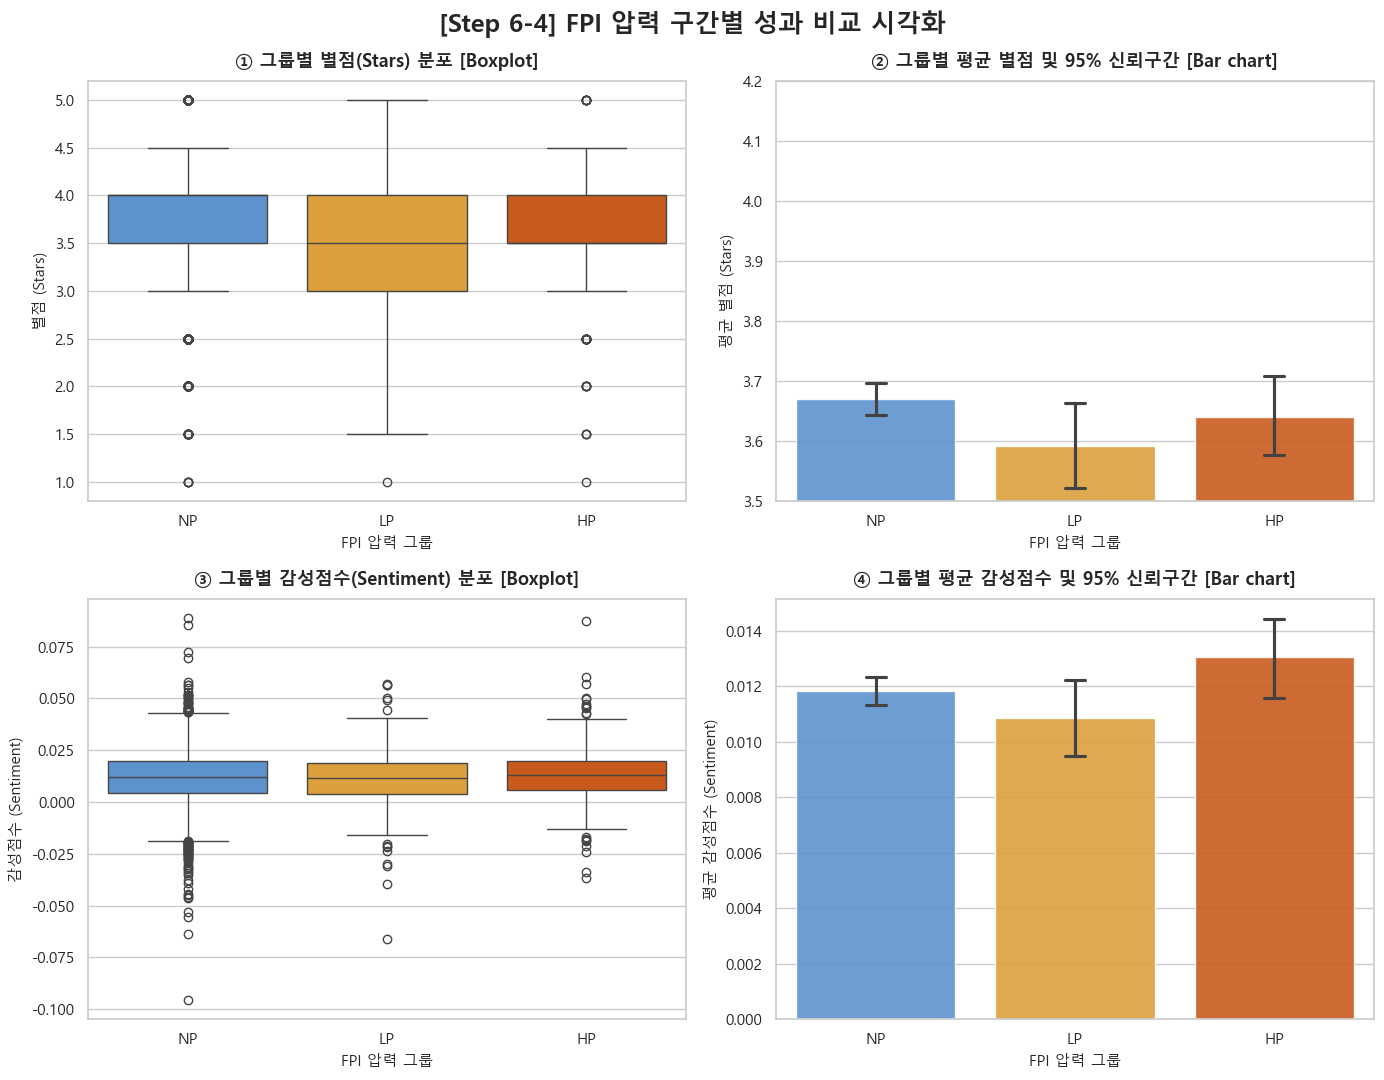

[결과 해석]  
  
  * 단순 집단 비교의 한계성(ANOVA 결과와 일치)  
    
  구간별 성과 비교 바차트(Bar Chart) 분석 결과, 무풍(NP)·저압력(LP)·고압력(HP) 세 집단의 95% 신뢰구간(CI) 에러바가 크게 중첩된다. 이는 집단 간 단순 평균 성과 차이가 통계적으로 유의미하지 않다는 일원분산분석(One-way ANOVA) 결과(P-value > 0.05)를 시각적으로 직접 증명한다.  
  * '통제 변수' 도입의 당위성 실증  
    
  매장 규모(리뷰 수) 및 지역 상권 특성 등 외생적 교란 요인을 통제하지 않은 단순 비교 환경에서는 프랜차이즈 밀집도(FPI)의 실질적 효과가 착시 효과에 의해 은폐됨을 확인하였다.  
  * 다중회귀분석(OLS) 모델과의 연계적 결론  
    
  외부 환경 요인을 엄격히 통제한 다중회귀모델 상에서는 FPI가 별점 성과에 통계적으로 유의미한 양(+)의 영향(P-value = 0.004)을 미치는 인과관계가 도출되었다.  


C:\Users\seonu\AppData\Local\Temp\ipykernel_20484\643061694.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], x='fpi_group', y='stars', data=indie_df_group, order=group_order, palette=colors)
C:\Users\seonu\AppData\Local\Temp\ipykernel_20484\643061694.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='fpi_group', y='stars', data=indie_df_group, order=group_order, palette=colors, errorbar=('ci', 95), capsize=0.1, alpha=0.9)
C:\Users\seonu\AppData\Local\Temp\ipykernel_20484\643061694.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

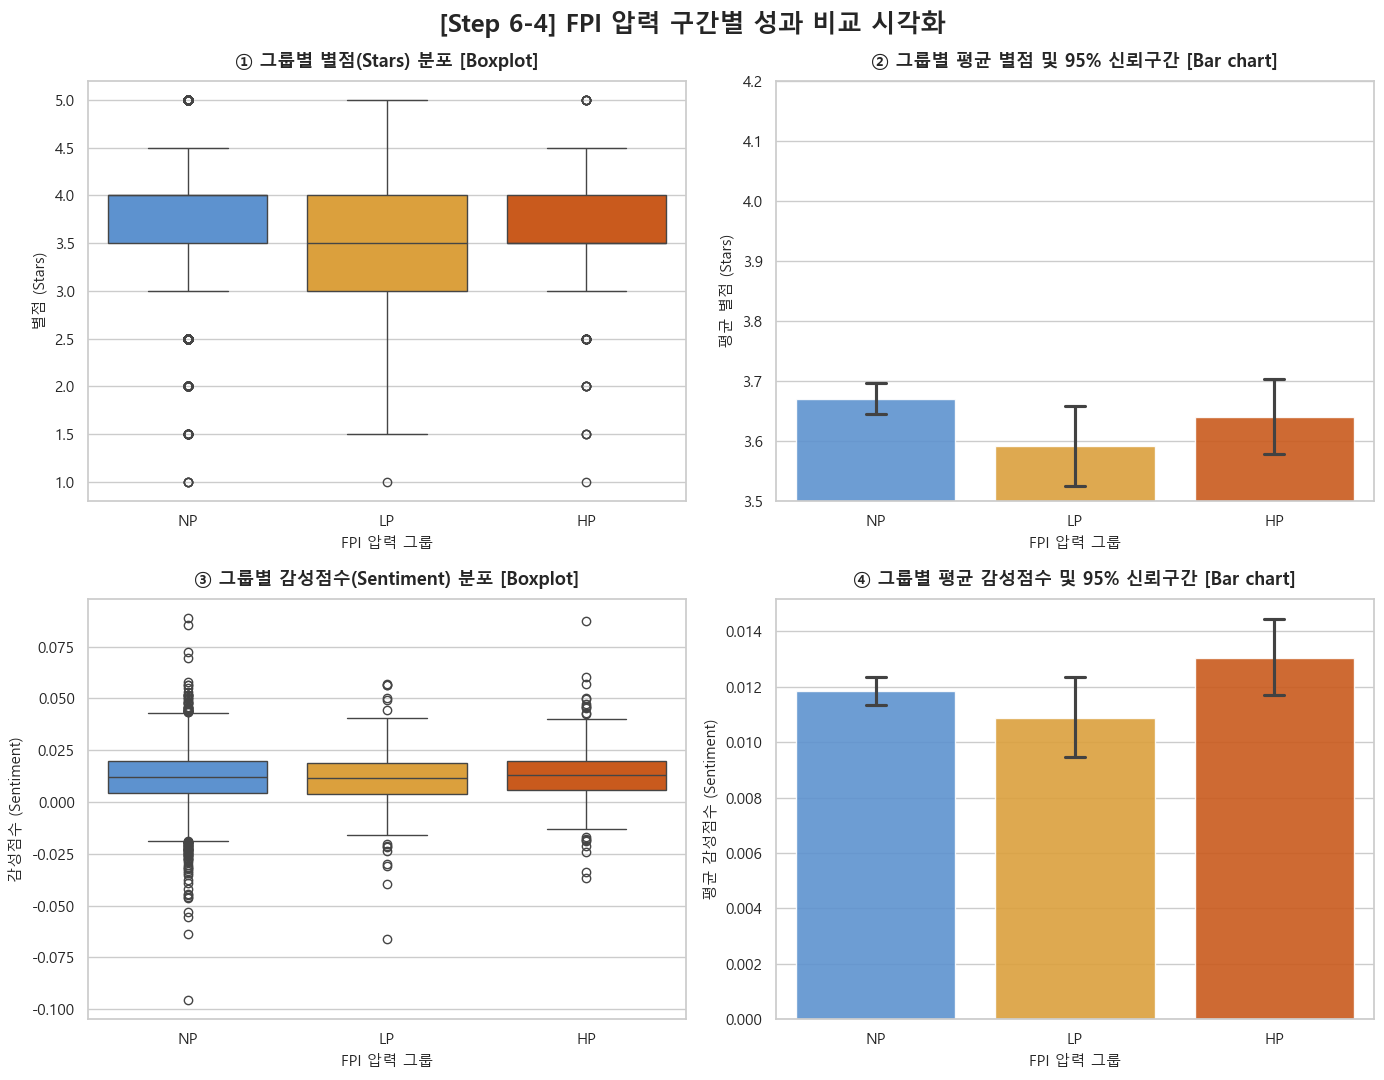

In [10]:
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid")
plt.rc('font', family='Malgun Gothic') 

group_order = ['NP', 'LP', 'HP']
indie_df_group['fpi_group'] = pd.Categorical(indie_df_group['fpi_group'], categories=group_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('[Step 6-4] FPI 압력 구간별 성과 비교 시각화', fontsize=18, fontweight='bold', y=0.98)

colors = ['#4a90e2', '#f5a623', '#e65100']

# =====================================================================
# [PART 1] 별점(Stars) 시각화
# =====================================================================
# 1-1. 별점 박스플롯
sns.boxplot(ax=axes[0, 0], x='fpi_group', y='stars', data=indie_df_group, order=group_order, palette=colors)
axes[0, 0].set_title('① 그룹별 별점(Stars) 분포 [Boxplot]', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('FPI 압력 그룹', fontsize=11)
axes[0, 0].set_ylabel('별점 (Stars)', fontsize=11)

# 1-2. 별점 평균 바차트 (95% 신뢰구간 에러바 포함)
sns.barplot(ax=axes[0, 1], x='fpi_group', y='stars', data=indie_df_group, order=group_order, palette=colors, errorbar=('ci', 95), capsize=0.1, alpha=0.9)
axes[0, 1].set_title('② 그룹별 평균 별점 및 95% 신뢰구간 [Bar chart]', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('FPI 압력 그룹', fontsize=11)
axes[0, 1].set_ylabel('평균 별점 (Stars)', fontsize=11)
axes[0, 1].set_ylim(3.5, 4.2)  


# =====================================================================
# [PART 2] 감성점수(Sentiment) 시각화
# =====================================================================
# 2-1. 감성점수 박스플롯
sns.boxplot(ax=axes[1, 0], x='fpi_group', y='tfidf_sentiment', data=indie_df_group, order=group_order, palette=colors)
axes[1, 0].set_title('③ 그룹별 감성점수(Sentiment) 분포 [Boxplot]', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('FPI 압력 그룹', fontsize=11)
axes[1, 0].set_ylabel('감성점수 (Sentiment)', fontsize=11)

# 2-2. 감성점수 평균 바차트 (95% 신뢰구간 에러바 포함)
sns.barplot(ax=axes[1, 1], x='fpi_group', y='tfidf_sentiment', data=indie_df_group, order=group_order, palette=colors, errorbar=('ci', 95), capsize=0.1, alpha=0.9)
axes[1, 1].set_title('④ 그룹별 평균 감성점수 및 95% 신뢰구간 [Bar chart]', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('FPI 압력 그룹', fontsize=11)
axes[1, 1].set_ylabel('평균 감성점수 (Sentiment)', fontsize=11)


# 레이아웃 정돈 및 이미지 저장
plt.tight_layout()
plt.savefig(f"{PATH_to_save}/fpi_results_visualization.png", dpi=300)
plt.show()